# 06 - Network-Based Safe Path Analysis

**目标：**
1. 🗺️ 下载费城道路网络（OSMnx）
2. 🔗 将 Risk Score 赋予道路网络边
3. 🚶 计算基于风险的最安全路径
4. 📤 导出结果供 ArcGIS 可视化

**参考：** MUSA 5500 Week 8B - Traffic Network Analysis using NetworkX

**运行前确保：**
- 已运行完 01-05 notebooks
- `finaldata/processed_data/final_analysis_with_predictions.shp` 存在

## 0. 安装和导入库

In [1]:
# 如果没有安装 OSMnx，先安装
# !pip install osmnx networkx

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, mapping
from shapely.ops import nearest_points
import warnings
warnings.filterwarnings('ignore')

# 设置 OSMnx
ox.settings.use_cache = True
ox.settings.log_console = True

print("✅ 库已导入")
print(f"OSMnx version: {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")

✅ 库已导入
OSMnx version: 2.0.6
NetworkX version: 3.4.2


## 1. 配置路径和加载数据

In [3]:
# 路径配置
DATA_DIR = "./finaldata"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_data")
OUTPUT_DIR = os.path.join(DATA_DIR, "network_analysis")

# 创建输出目录
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 加载 Risk Score 数据
risk_data_path = os.path.join(PROCESSED_DIR, "final_analysis_with_predictions.shp")

if os.path.exists(risk_data_path):
    gdf_risk = gpd.read_file(risk_data_path)
    print(f"✅ 加载了 {len(gdf_risk)} 个 Block Groups")
    print(f"CRS: {gdf_risk.crs}")
else:
    raise FileNotFoundError(f"找不到文件: {risk_data_path}")

✅ 加载了 1283 个 Block Groups
CRS: EPSG:4326


In [4]:
# 检查 risk score 相关字段
risk_columns = [col for col in gdf_risk.columns if 'risk' in col.lower() or 'score' in col.lower() or 'priority' in col.lower()]
print("Risk 相关字段:")
for col in risk_columns:
    print(f"  - {col}")

# 查看 priority 字段的分布（这是我们的综合风险评分）
print("\npriority 字段统计:")
print(gdf_risk['priority'].describe())

Risk 相关字段:
  - dark_score
  - priority
  - risk_score
  - risk_level
  - risk_100

priority 字段统计:
count    1283.000000
mean        0.687025
std         0.071432
min         0.257961
25%         0.662907
50%         0.708633
75%         0.733249
max         0.831380
Name: priority, dtype: float64


## 2. 下载费城道路网络 🗺️

使用 OSMnx 从 OpenStreetMap 下载费城的步行道路网络

In [5]:
# 定义费城边界
place_name = "Philadelphia, Pennsylvania, USA"

# 检查是否已缓存网络
network_cache_path = os.path.join(OUTPUT_DIR, "philly_walk_network.graphml")

if os.path.exists(network_cache_path):
    print("📂 从缓存加载道路网络...")
    G = ox.load_graphml(network_cache_path)
    print(f"✅ 加载完成")
else:
    print("🌐 从 OpenStreetMap 下载道路网络...")
    print("   这可能需要几分钟，请耐心等待...")
    
    # 下载步行网络
    G = ox.graph_from_place(
        place_name, 
        network_type='walk',  # 步行网络
        simplify=True
    )
    
    # 保存缓存
    ox.save_graphml(G, network_cache_path)
    print(f"✅ 下载完成，已保存到: {network_cache_path}")

print(f"\n网络统计:")
print(f"  节点数: {G.number_of_nodes():,}")
print(f"  边数: {G.number_of_edges():,}")

📂 从缓存加载道路网络...
✅ 加载完成

网络统计:
  节点数: 115,032
  边数: 340,482


In [6]:
# 将网络投影到与 risk_data 相同的 CRS
# OSMnx 默认是 WGS84 (EPSG:4326)
print(f"网络 CRS: {G.graph['crs']}")
print(f"Risk 数据 CRS: {gdf_risk.crs}")

# 如果需要，转换 CRS（使用投影坐标系计算距离更准确）
# 使用 Pennsylvania State Plane South (EPSG:2272) 或 UTM
G_proj = ox.project_graph(G, to_crs="EPSG:2272")
gdf_risk_proj = gdf_risk.to_crs("EPSG:2272")

print("\n✅ 已投影到 EPSG:2272 (PA State Plane South)")

网络 CRS: epsg:4326
Risk 数据 CRS: EPSG:4326

✅ 已投影到 EPSG:2272 (PA State Plane South)


## 3. 将 Risk Score 赋予道路边 🔗

核心步骤：通过空间连接，将每条道路边与其所在的 Block Group 的 risk score 关联

In [7]:
# 将网络边转换为 GeoDataFrame
edges_gdf = ox.graph_to_gdfs(G_proj, nodes=False, edges=True)
print(f"道路边数量: {len(edges_gdf):,}")
edges_gdf.head()

道路边数量: 340,482


osmid      highway               name  oneway  \
u         v         key                                                      
109726936 109726940 0     12108955  residential     Brunner Street   False   
          109992543 0     43226669      primary  Germantown Avenue   False   
          109992535 0     43226669      primary  Germantown Avenue   False   
109726940 109726936 0     12108955  residential     Brunner Street   False   
          109726950 0    302956448  residential       Wayne Avenue   False   

                        reversed      length lanes maxspeed       service  \
u         v         key                                                     
109726936 109726940 0      False  174.382306   NaN      NaN           NaN   
          109992543 0      False   55.073821     2   25 mph  disused_tram   
          109992535 0       True    7.177834     2   25 mph  disused_tram   
109726940 109726936 0       True  174.382306   NaN      NaN           NaN   
          109726950 0      False   11.447633   NaN      NaN           NaN   

                                                                  geometry  \
u         v         key                                                      
109726936 109726940 0    LINESTRING (2695094.158 260317.651, 2694612.05...   
          109992543 0    LINESTRING (2695094.158 260317.651, 2695012.92...   
          109992535 0    LINESTRING (2695094.158 260317.651, 2695105.13...   
109726940 109726936 0    LINESTRING (2694612.051 260008.07, 2695094.158...   
          109726950 0    LINESTRING (2694612.051 260008.07, 2694632.286...   

                        bridge access  ref tunnel width junction area  
u         v         key                                                
109726936 109726940 0      NaN    NaN  NaN    NaN   NaN      NaN  NaN  
          109992543 0      NaN    NaN  NaN    NaN   NaN      NaN  NaN  
          109992535 0      NaN    NaN  NaN    NaN   NaN      NaN  NaN  
109726940 109726936 0      NaN    NaN  NaN    NaN   NaN      NaN  NaN  
          109726950 0      NaN    NaN  NaN    NaN   NaN      NaN  NaN

In [8]:
# 计算每条边的中点（用于空间连接）
edges_gdf['edge_midpoint'] = edges_gdf.geometry.interpolate(0.5, normalized=True)

# 创建中点 GeoDataFrame 用于空间连接
midpoints_gdf = edges_gdf.copy()
midpoints_gdf = midpoints_gdf.set_geometry('edge_midpoint')

print("✅ 计算了边的中点")

✅ 计算了边的中点


In [9]:
# 空间连接：将边的中点与 Block Group 匹配
print("🔗 执行空间连接...")

# 只保留需要的列以加速
risk_simple = gdf_risk_proj[['GEOID', 'priority', 'pri_level', 'geometry']].copy()

# 空间连接
edges_with_risk = gpd.sjoin(
    midpoints_gdf,
    risk_simple,
    how='left',
    predicate='within'
)

print(f"✅ 空间连接完成")
print(f"   匹配到 risk score 的边: {edges_with_risk['priority'].notna().sum():,}")
print(f"   未匹配的边: {edges_with_risk['priority'].isna().sum():,}")

🔗 执行空间连接...
✅ 空间连接完成
   匹配到 risk score 的边: 309,262
   未匹配的边: 31,220


In [10]:
# 处理未匹配的边（给予中等风险值）
median_priority = gdf_risk_proj['priority'].median()
edges_with_risk['priority'] = edges_with_risk['priority'].fillna(median_priority)

print(f"未匹配的边使用中位数风险值: {median_priority:.2f}")

# 创建 risk_score 字段（归一化到合理范围）
# priority 越高 = 风险越高 = 路径成本越高
edges_with_risk['risk_score'] = edges_with_risk['priority']

print("\nRisk Score 统计:")
print(edges_with_risk['risk_score'].describe())

未匹配的边使用中位数风险值: 0.71

Risk Score 统计:
count    340482.000000
mean          0.687997
std           0.067076
min           0.257961
25%           0.668367
50%           0.708633
75%           0.728734
max           0.831380
Name: risk_score, dtype: float64


In [11]:
# 将 risk_score 更新回网络图的边属性
print("🔄 更新网络图的边权重...")
print("   使用与 ArcGIS Cost Surface 一致的计算方式")

# 创建边索引到 risk_score 的映射
risk_dict = edges_with_risk['risk_score'].to_dict()

# priority 范围统计
risk_values = list(risk_dict.values())
print(f"   Priority 范围: {min(risk_values):.3f} - {max(risk_values):.3f}")

# 更新图的边属性
for (u, v, key), risk in risk_dict.items():
    if G_proj.has_edge(u, v, key):
        G_proj[u][v][key]['risk_score'] = risk
        length = G_proj[u][v][key].get('length', 100)
        
        # ============================================
        # 与 ArcGIS Cost Surface 一致的计算方式
        # ============================================
        # priority 是 0-1 范围，转换成 1-5 等级
        # 对应 ArcGIS 里的 Low(1) - Critical(5)
        priority_1to5 = 1 + risk * 4  # 0→1, 1→5
        
        # Cost = length × priority等级
        # 这样最危险的路成本是最安全的 5 倍
        G_proj[u][v][key]['risk_cost'] = length * priority_1to5

print("✅ 边权重更新完成")
print("   风险成本 = 距离 × Priority(1-5)")
print("   最安全路段: cost = length × 1")
print("   最危险路段: cost = length × 5")

🔄 更新网络图的边权重...
   使用与 ArcGIS Cost Surface 一致的计算方式
   Priority 范围: 0.258 - 0.831
✅ 边权重更新完成
   风险成本 = 距离 × Priority(1-5)
   最安全路段: cost = length × 1
   最危险路段: cost = length × 5


## 4. 定义起点和终点 📍

设置要计算安全路径的地点

In [12]:
# 定义关键地点（WGS84 坐标）
# 🎓 Penn学生完整步行路线：大学城 + 市中心
locations = {
    # ========== 大学城 - 学生公寓 ==========
    'The Accolade': (-75.1920, 39.9565),          # 你住的地方！
    'The Standard': (-75.1885, 39.9540),          # Standard at Philadelphia
    'EVO at Cira': (-75.1835, 39.9560),           # EVO Cira Centre South
    'The Radian': (-75.1970, 39.9545),            # The Radian
    'Chestnut Hall': (-75.2010, 39.9555),         # 更西边
    'University City Townhomes': (-75.2050, 39.9530),  # 西边townhomes区域
    'HUB on Chestnut': (-75.2000, 39.9550),       # Hub on Chestnut
    
    # ========== 大学城 - 宾大校园 ==========
    'Wharton (Huntsman Hall)': (-75.1985, 39.9530),   # 沃顿商学院
    'Weitzman (Design School)': (-75.1925, 39.9520),  # 设计学院 (Meyerson Hall)
    'Van Pelt Library': (-75.1935, 39.9525),          # 图书馆
    'Houston Hall': (-75.1940, 39.9510),              # 学生中心
    'Penn Engineering': (-75.1905, 39.9520),          # 工程学院
    'Fisher Fine Arts': (-75.1928, 39.9518),          # 美术图书馆
    
    # ========== 大学城 - 超市便利店 ==========
    'Trader Joes (Market St)': (-75.1755, 39.9535),   # Trader Joe's
    'Whole Foods (Penn)': (-75.1870, 39.9505),        # Whole Foods on South St
    'Fresh Grocer (40th St)': (-75.2010, 39.9560),    # Fresh Grocer 大学城
    'CVS (36th & Walnut)': (-75.1950, 39.9530),       # CVS 药店
    'Wawa (30th St)': (-75.1820, 39.9545),            # Wawa 便利店
    
    # ========== 大学城 - 交通枢纽 ==========
    '30th Street Station': (-75.1820, 39.9557),       # 主火车站
    'University City Station': (-75.1915, 39.9490),   # 大学城SEPTA站
    '40th Street Portal': (-75.2020, 39.9555),        # 40街地铁入口
    
    # ========== 大学城 - 餐饮社交 ==========
    'Walnut Street Bars': (-75.1900, 39.9530),        # 酒吧区
    'Food Trucks (33rd)': (-75.1900, 39.9500),        # 食品车区域
    
    # ========== 市中心 - 交通枢纽 ==========
    'Suburban Station': (-75.1680, 39.9538),          # 市中心地下车站
    'Jefferson Station': (-75.1585, 39.9525),         # Jefferson站
    
    # ========== 市中心 - 大型超市 ==========
    'Target (Center City)': (-75.1608, 39.9513),      # 1128 Chestnut St - 买大件！
    'Giant Heirloom (Center City)': (-75.1695, 39.9530),  # Giant Heirloom
    'Whole Foods (Center City)': (-75.1720, 39.9620), # 2101 Pennsylvania Ave
    
    # ========== 市中心 - Chinatown 中超 ==========
    'Asianfresh (Chinatown)': (-75.1535, 39.9555),    # N 10th & Race - 最大中超
    'Heng Fa (Chinatown)': (-75.1545, 39.9565),       # 10th & Cherry - 老牌
    'EnJoy Market (Chinatown)': (-75.1540, 39.9550),  # 143 N 11th St
    
    # ========== 市中心 - 娱乐街区 ==========
    'South Street': (-75.1475, 39.9425),              # 娱乐一条街
    'Old City Bars': (-75.1455, 39.9505),             # Old City 酒吧区
    'Rittenhouse Square': (-75.1715, 39.9496),        # 高端餐厅区
    '13th Street (Gayborhood)': (-75.1620, 39.9510),  # Midtown Village
    'Avenue of the Arts': (-75.1650, 39.9480),        # South Broad - 剧院街
    'Reading Terminal Market': (-75.1590, 39.9535),   # 美食市场
}

print(f"📍 定义了 {len(locations)} 个地点")
print("\n=== 地点分布 ===")
print("  🏠 学生公寓: 7 个")
print("  🎓 宾大校园: 6 个")
print("  🛒 大学城超市: 5 个")
print("  🚂 大学城交通: 3 个")
print("  🚇 市中心车站: 2 个")
print("  🛍️ 市中心超市: 3 个")
print("  🥢 Chinatown中超: 3 个")
print("  🎭 娱乐街区: 6 个")

📍 定义了 37 个地点

=== 地点分布 ===
  🏠 学生公寓: 7 个
  🎓 宾大校园: 6 个
  🛒 大学城超市: 5 个
  🚂 大学城交通: 3 个
  🚇 市中心车站: 2 个
  🛍️ 市中心超市: 3 个
  🥢 Chinatown中超: 3 个
  🎭 娱乐街区: 6 个


In [13]:
# 将地点坐标 snap 到最近的网络节点
# 注意：ox.nearest_nodes 需要 WGS84 坐标

# 使用非投影图来查找节点
location_nodes = {}

for name, (lon, lat) in locations.items():
    # 找到最近的节点
    nearest_node = ox.nearest_nodes(G, lon, lat)
    location_nodes[name] = nearest_node
    
    # 获取节点坐标
    node_data = G.nodes[nearest_node]
    print(f"{name}: Node {nearest_node} at ({node_data['y']:.4f}, {node_data['x']:.4f})")

print("\n✅ 所有地点已映射到网络节点")

The Accolade: Node 8838558344 at (39.9566, -75.1921)
The Standard: Node 4696697720 at (39.9539, -75.1888)
EVO at Cira: Node 780913814 at (39.9559, -75.1836)
The Radian: Node 11108253435 at (39.9543, -75.1974)
Chestnut Hall: Node 4476162819 at (39.9555, -75.2010)
University City Townhomes: Node 7863284871 at (39.9532, -75.2053)
HUB on Chestnut: Node 11874282257 at (39.9553, -75.2000)
Wharton (Huntsman Hall): Node 7002579265 at (39.9530, -75.1989)
Weitzman (Design School): Node 7918772143 at (39.9519, -75.1924)
Van Pelt Library: Node 1612613263 at (39.9523, -75.1935)
Houston Hall: Node 10751019930 at (39.9510, -75.1938)
Penn Engineering: Node 4696697750 at (39.9518, -75.1901)
Fisher Fine Arts: Node 10960207836 at (39.9516, -75.1930)
Trader Joes (Market St): Node 5675590479 at (39.9536, -75.1757)
Whole Foods (Penn): Node 3355024554 at (39.9505, -75.1870)
Fresh Grocer (40th St): Node 5886328382 at (39.9561, -75.2006)
CVS (36th & Walnut): Node 4696697705 at (39.9531, -75.1949)
Wawa (30th St

## 5. 计算最短路径 vs 最安全路径 🚶

对比两种路径：
- **最短路径**: 基于距离
- **最安全路径**: 基于风险成本

In [14]:
def calculate_paths(G, origin_name, dest_name, location_nodes):
    """
    计算两点之间的最短路径和最安全路径
    """
    origin = location_nodes[origin_name]
    dest = location_nodes[dest_name]
    
    # 最短路径（基于距离）
    try:
        shortest_path = nx.shortest_path(G, origin, dest, weight='length')
        shortest_length = nx.shortest_path_length(G, origin, dest, weight='length')
    except nx.NetworkXNoPath:
        print(f"⚠️ 无法找到从 {origin_name} 到 {dest_name} 的路径")
        return None
    
    # 最安全路径（基于风险成本）
    try:
        safest_path = nx.shortest_path(G, origin, dest, weight='risk_cost')
        safest_cost = nx.shortest_path_length(G, origin, dest, weight='risk_cost')
    except:
        # 如果 risk_cost 不存在，使用 length
        safest_path = shortest_path
        safest_cost = shortest_length
    
    # 计算路径统计
    def path_stats(path, G):
        total_length = 0
        total_risk = 0
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            edge_data = G.get_edge_data(u, v)
            if edge_data:
                # 获取第一条边（可能有多条平行边）
                first_edge = list(edge_data.values())[0]
                total_length += first_edge.get('length', 0)
                total_risk += first_edge.get('risk_score', 50)
        avg_risk = total_risk / max(len(path) - 1, 1)
        return total_length, avg_risk
    
    shortest_stats = path_stats(shortest_path, G)
    safest_stats = path_stats(safest_path, G)
    
    return {
        'origin': origin_name,
        'destination': dest_name,
        'shortest_path': shortest_path,
        'shortest_length_m': shortest_stats[0],
        'shortest_avg_risk': shortest_stats[1],
        'safest_path': safest_path,
        'safest_length_m': safest_stats[0],
        'safest_avg_risk': safest_stats[1],
    }

In [15]:
# 定义要计算的路线对
route_pairs = [
    # ========== 大学城内部：公寓 → 超市 ==========
    ('The Accolade', 'Trader Joes (Market St)'),
    ('The Accolade', 'Whole Foods (Penn)'),
    ('The Accolade', 'Fresh Grocer (40th St)'),
    ('The Standard', 'Trader Joes (Market St)'),
    ('EVO at Cira', 'Whole Foods (Penn)'),
    ('The Radian', 'Fresh Grocer (40th St)'),
    ('Chestnut Hall', 'CVS (36th & Walnut)'),
    ('University City Townhomes', 'Fresh Grocer (40th St)'),
    
    # ========== 大学城内部：公寓 → 校园 ==========
    ('The Accolade', 'Wharton (Huntsman Hall)'),
    ('The Accolade', 'Weitzman (Design School)'),
    ('The Accolade', 'Van Pelt Library'),
    ('The Standard', 'Penn Engineering'),
    ('EVO at Cira', 'Wharton (Huntsman Hall)'),
    ('The Radian', 'Fisher Fine Arts'),
    ('HUB on Chestnut', 'Van Pelt Library'),
    
    # ========== 大学城内部：公寓 → 交通站 ==========
    ('The Accolade', '30th Street Station'),
    ('The Accolade', 'University City Station'),
    ('The Standard', '30th Street Station'),
    ('EVO at Cira', '30th Street Station'),
    ('The Radian', '40th Street Portal'),
    ('University City Townhomes', '40th Street Portal'),
    
    # ========== 大学城内部：校园移动 ==========
    ('Wharton (Huntsman Hall)', 'Van Pelt Library'),
    ('Weitzman (Design School)', 'Houston Hall'),
    ('Penn Engineering', 'Wharton (Huntsman Hall)'),
    
    # ========== 大学城内部：社交/便利店 ==========
    ('The Accolade', 'Walnut Street Bars'),
    ('The Accolade', 'Wawa (30th St)'),
    ('The Accolade', 'CVS (36th & Walnut)'),
    ('Van Pelt Library', 'Food Trucks (33rd)'),
    ('Van Pelt Library', 'Wawa (30th St)'),
    
    # ========== 市中心：车站 → Target购物 ==========
    ('Suburban Station', 'Target (Center City)'),
    ('Jefferson Station', 'Target (Center City)'),
    ('30th Street Station', 'Target (Center City)'),
    
    # ========== 市中心：车站 → Chinatown中超 ==========
    ('Suburban Station', 'Asianfresh (Chinatown)'),
    ('Suburban Station', 'Heng Fa (Chinatown)'),
    ('Jefferson Station', 'Asianfresh (Chinatown)'),
    ('Jefferson Station', 'Heng Fa (Chinatown)'),
    ('Reading Terminal Market', 'Asianfresh (Chinatown)'),
    
    # ========== 市中心：车站 → 娱乐街区 ==========
    ('Suburban Station', 'South Street'),
    ('Suburban Station', 'Old City Bars'),
    ('Suburban Station', 'Rittenhouse Square'),
    ('Suburban Station', '13th Street (Gayborhood)'),
    ('Jefferson Station', 'South Street'),
    ('Jefferson Station', 'Old City Bars'),
    
    # ========== 市中心：娱乐区之间 ==========
    ('Rittenhouse Square', 'South Street'),
    ('Rittenhouse Square', '13th Street (Gayborhood)'),
    ('Old City Bars', 'South Street'),
    ('Reading Terminal Market', '13th Street (Gayborhood)'),
    
    # ========== 市中心：看演出 ==========
    ('Suburban Station', 'Avenue of the Arts'),
    ('Rittenhouse Square', 'Avenue of the Arts'),
    
    # ========== 跨区长距离 ==========
    ('30th Street Station', 'Asianfresh (Chinatown)'),
    ('30th Street Station', 'South Street'),
    ('The Accolade', 'Rittenhouse Square'),
]

print(f"🚶 定义了 {len(route_pairs)} 条路线")
print("\n=== 路线分布 ===")
print("  🛒 大学城 公寓→超市: 8 条")
print("  🎓 大学城 公寓→校园: 7 条")
print("  🚂 大学城 公寓→车站: 6 条")
print("  📚 大学城 校园内移动: 3 条")
print("  🍺 大学城 社交/便利店: 5 条")
print("  🎯 市中心 车站→Target: 3 条")
print("  🥢 市中心 车站→Chinatown: 5 条")
print("  🎉 市中心 车站→娱乐区: 6 条")
print("  🔄 市中心 娱乐区之间: 4 条")
print("  🎭 市中心 看演出: 2 条")
print("  🚶 跨区长距离: 3 条")

# 计算所有路线
all_routes = []

print("\n" + "=" * 80)
print("🚶 开始计算路径...")
print("=" * 80)

for i, (origin, dest) in enumerate(route_pairs):
    result = calculate_paths(G_proj, origin, dest, location_nodes)
    if result:
        all_routes.append(result)
        
        # 简洁输出
        dist_diff = (result['safest_length_m'] - result['shortest_length_m']) / result['shortest_length_m'] * 100
        risk_diff = (result['safest_avg_risk'] - result['shortest_avg_risk']) / result['shortest_avg_risk'] * 100 if result['shortest_avg_risk'] > 0 else 0
        
        # 只显示有差异的路线
        if abs(dist_diff) > 0.1 or abs(risk_diff) > 0.1:
            print(f"\n✨ {origin} → {dest}")
            print(f"   最短: {result['shortest_length_m']:.0f}m, 风险: {result['shortest_avg_risk']:.2f}")
            print(f"   最安全: {result['safest_length_m']:.0f}m, 风险: {result['safest_avg_risk']:.2f}")
            print(f"   → 多走 {dist_diff:+.1f}%, 风险 {risk_diff:+.1f}%")

print("\n" + "=" * 80)
print(f"✅ 计算完成 {len(all_routes)} 条路线")

🚶 定义了 52 条路线

=== 路线分布 ===
  🛒 大学城 公寓→超市: 8 条
  🎓 大学城 公寓→校园: 7 条
  🚂 大学城 公寓→车站: 6 条
  📚 大学城 校园内移动: 3 条
  🍺 大学城 社交/便利店: 5 条
  🎯 市中心 车站→Target: 3 条
  🥢 市中心 车站→Chinatown: 5 条
  🎉 市中心 车站→娱乐区: 6 条
  🔄 市中心 娱乐区之间: 4 条
  🎭 市中心 看演出: 2 条
  🚶 跨区长距离: 3 条

🚶 开始计算路径...

✨ The Accolade → Trader Joes (Market St)
   最短: 1537m, 风险: 0.64
   最安全: 1569m, 风险: 0.60
   → 多走 +2.0%, 风险 -6.9%

✨ The Accolade → Fresh Grocer (40th St)
   最短: 877m, 风险: 0.70
   最安全: 883m, 风险: 0.67
   → 多走 +0.7%, 风险 -3.2%

✨ The Standard → Trader Joes (Market St)
   最短: 1279m, 风险: 0.59
   最安全: 1287m, 风险: 0.57
   → 多走 +0.6%, 风险 -4.6%

✨ The Accolade → Wharton (Huntsman Hall)
   最短: 1012m, 风险: 0.65
   最安全: 1014m, 风险: 0.64
   → 多走 +0.2%, 风险 -1.2%

✨ EVO at Cira → Wharton (Huntsman Hall)
   最短: 1602m, 风险: 0.65
   最安全: 1602m, 风险: 0.65
   → 多走 +0.0%, 风险 -0.2%

✨ HUB on Chestnut → Van Pelt Library
   最短: 827m, 风险: 0.67
   最安全: 828m, 风险: 0.66
   → 多走 +0.1%, 风险 -1.8%

✨ The Accolade → Walnut Street Bars
   最短: 571m, 风险: 0.66
   最安全: 571m, 风险:

## 6. 导出路径为 Shapefile 📤

将计算的路径导出，以便在 ArcGIS 中可视化

In [16]:
def path_to_linestring(path, G):
    """
    将节点路径转换为 LineString
    """
    coords = []
    for node in path:
        node_data = G.nodes[node]
        coords.append((node_data['x'], node_data['y']))
    return LineString(coords)

# 创建路径 GeoDataFrame
path_records = []

for route in all_routes:
    # 最短路径
    path_records.append({
        'route_id': f"{route['origin']}_to_{route['destination']}".replace(' ', '_'),
        'origin': route['origin'],
        'destination': route['destination'],
        'path_type': 'shortest',
        'length_m': route['shortest_length_m'],
        'avg_risk': route['shortest_avg_risk'],
        'geometry': path_to_linestring(route['shortest_path'], G)  # 使用非投影图获取WGS84坐标
    })
    
    # 最安全路径
    path_records.append({
        'route_id': f"{route['origin']}_to_{route['destination']}".replace(' ', '_'),
        'origin': route['origin'],
        'destination': route['destination'],
        'path_type': 'safest',
        'length_m': route['safest_length_m'],
        'avg_risk': route['safest_avg_risk'],
        'geometry': path_to_linestring(route['safest_path'], G)
    })

# 创建 GeoDataFrame
paths_gdf = gpd.GeoDataFrame(path_records, crs="EPSG:4326")
print(f"✅ 创建了 {len(paths_gdf)} 条路径")
paths_gdf.head(10)

✅ 创建了 104 条路径


,route_id,origin,destination,path_type,length_m,avg_risk,geometry
0,The_Accolade_to_Trader_Joes_(Market_St),The Accolade,Trader Joes (Market St),shortest,1537.358247,0.641216,"LINESTRING (-75.19208 39.95664, -75.19144 39.9..."
1,The_Accolade_to_Trader_Joes_(Market_St),The Accolade,Trader Joes (Market St),safest,1568.598035,0.597258,"LINESTRING (-75.19208 39.95664, -75.19144 39.9..."
2,The_Accolade_to_Whole_Foods_(Penn),The Accolade,Whole Foods (Penn),shortest,1159.942796,0.628015,"LINESTRING (-75.19208 39.95664, -75.19144 39.9..."
3,The_Accolade_to_Whole_Foods_(Penn),The Accolade,Whole Foods (Penn),safest,1159.942796,0.628015,"LINESTRING (-75.19208 39.95664, -75.19144 39.9..."
4,The_Accolade_to_Fresh_Grocer_(40th_St),The Accolade,Fresh Grocer (40th St),shortest,876.922400,0.695506,"LINESTRING (-75.19208 39.95664, -75.19221 39.9..."
5,The_Accolade_to_Fresh_Grocer_(40th_St),The Accolade,Fresh Grocer (40th St),safest,883.258433,0.672988,"LINESTRING (-75.19208 39.95664, -75.19221 39.9..."
6,The_Standard_to_Trader_Joes_(Market_St),The Standard,Trader Joes (Market St),shortest,1279.066178,0.594588,"LINESTRING (-75.1888 39.95389, -75.18757 39.95..."
7,The_Standard_to_Trader_Joes_(Market_St),The Standard,Trader Joes (Market St),safest,1286.972398,0.567020,"LINESTRING (-75.1888 39.95389, -75.18757 39.95..."
8,EVO_at_Cira_to_Whole_Foods_(Penn),EVO at Cira,Whole Foods (Penn),shortest,846.836897,0.642924,"LINESTRING (-75.18362 39.95594, -75.18323 39.9..."
9,EVO_at_Cira_to_Whole_Foods_(Penn),EVO at Cira,Whole Foods (Penn),safest,846.836897,0.642924,"LINESTRING (-75.18362 39.95594, -75.18323 39.9..."


In [17]:
# 导出为多种格式

# Shapefile
shp_path = os.path.join(OUTPUT_DIR, "safe_paths.shp")
paths_gdf.to_file(shp_path)
print(f"✅ 导出 Shapefile: {shp_path}")

# GeoJSON (用于 Web)
geojson_path = os.path.join(OUTPUT_DIR, "safe_paths.geojson")
paths_gdf.to_file(geojson_path, driver='GeoJSON')
print(f"✅ 导出 GeoJSON: {geojson_path}")

# GPKG
gpkg_path = os.path.join(OUTPUT_DIR, "safe_paths.gpkg")
paths_gdf.to_file(gpkg_path, driver='GPKG')
print(f"✅ 导出 GPKG: {gpkg_path}")

✅ 导出 Shapefile: ./finaldata\network_analysis\safe_paths.shp
✅ 导出 GeoJSON: ./finaldata\network_analysis\safe_paths.geojson
✅ 导出 GPKG: ./finaldata\network_analysis\safe_paths.gpkg


In [18]:
# 同时导出地点点位
location_records = []
for name, (lon, lat) in locations.items():
    location_records.append({
        'name': name,
        'geometry': Point(lon, lat)
    })

locations_gdf = gpd.GeoDataFrame(location_records, crs="EPSG:4326")
locations_gdf.to_file(os.path.join(OUTPUT_DIR, "route_locations.shp"))
print(f"✅ 导出地点: {os.path.join(OUTPUT_DIR, 'route_locations.shp')}")

✅ 导出地点: ./finaldata\network_analysis\route_locations.shp


## 7. 可视化路径 🗺️

✅ 保存图片: ./finaldata\network_analysis\path_comparison.png


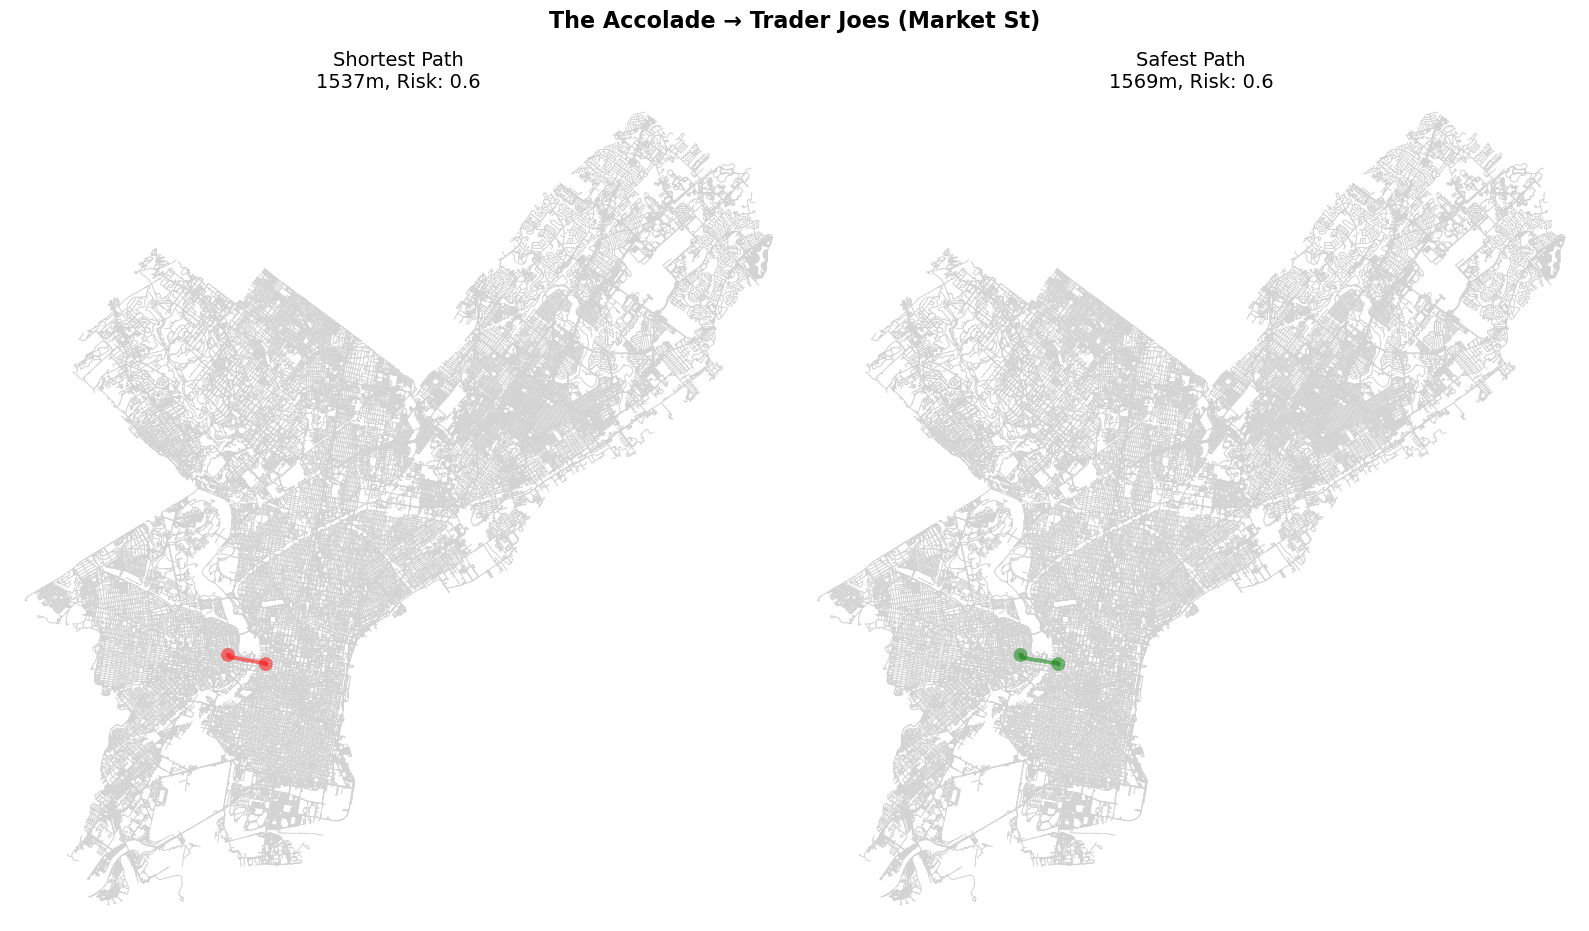

In [19]:
# 创建对比图：City Hall → Temple University
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 获取这条路线的数据
route = all_routes[0]  # City Hall → Temple

# 左图：最短路径
ax1 = axes[0]
ox.plot_graph(
    G, ax=ax1, 
    node_size=0, edge_color='lightgray', edge_linewidth=0.5,
    show=False, close=False
)
ox.plot_graph_route(
    G, route['shortest_path'], 
    ax=ax1, route_color='red', route_linewidth=3,
    show=False, close=False
)
ax1.set_title(f"Shortest Path\n{route['shortest_length_m']:.0f}m, Risk: {route['shortest_avg_risk']:.1f}", fontsize=14)

# 右图：最安全路径
ax2 = axes[1]
ox.plot_graph(
    G, ax=ax2,
    node_size=0, edge_color='lightgray', edge_linewidth=0.5,
    show=False, close=False
)
ox.plot_graph_route(
    G, route['safest_path'],
    ax=ax2, route_color='green', route_linewidth=3,
    show=False, close=False
)
ax2.set_title(f"Safest Path\n{route['safest_length_m']:.0f}m, Risk: {route['safest_avg_risk']:.1f}", fontsize=14)

plt.suptitle(f"{route['origin']} → {route['destination']}", fontsize=16, fontweight='bold')
plt.tight_layout()

# 保存图片
fig_path = os.path.join(OUTPUT_DIR, "path_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✅ 保存图片: {fig_path}")

plt.show()

✅ 保存图片: ./finaldata\network_analysis\all_safe_routes.png


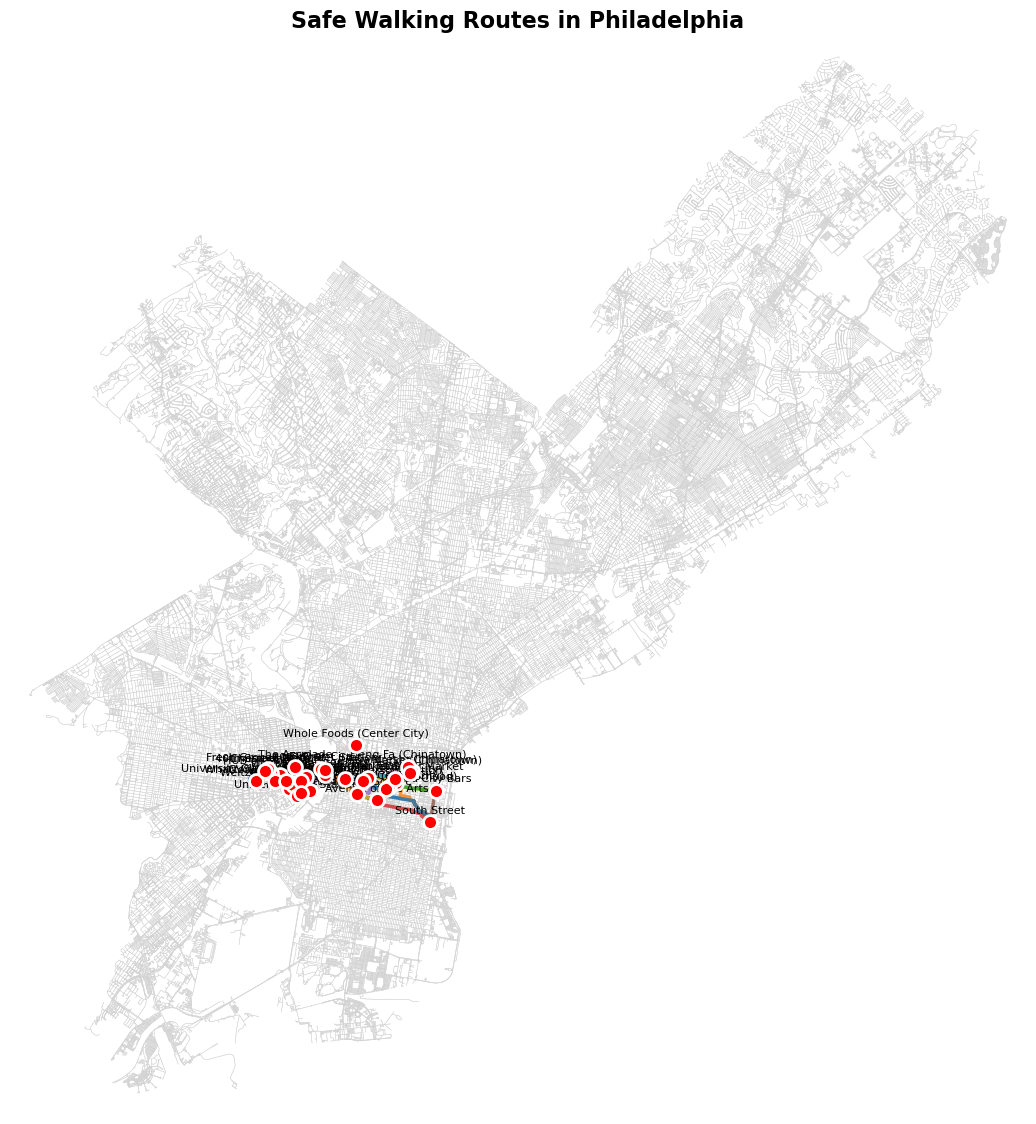

In [20]:
# 创建所有路线的汇总图
fig, ax = plt.subplots(figsize=(14, 14))

# 绘制底图
ox.plot_graph(
    G, ax=ax,
    node_size=0, edge_color='lightgray', edge_linewidth=0.3,
    show=False, close=False
)

# 绘制所有最安全路径
colors = plt.cm.tab10.colors
for i, route in enumerate(all_routes):
    color = colors[i % len(colors)]
    ox.plot_graph_route(
        G, route['safest_path'],
        ax=ax, route_color=color, route_linewidth=2.5, route_alpha=0.8,
        show=False, close=False
    )

# 标记地点
for name, (lon, lat) in locations.items():
    ax.scatter(lon, lat, c='red', s=100, zorder=5, edgecolors='white', linewidths=2)
    ax.annotate(name, (lon, lat), fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title("Safe Walking Routes in Philadelphia", fontsize=16, fontweight='bold')

# 保存
fig_path = os.path.join(OUTPUT_DIR, "all_safe_routes.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✅ 保存图片: {fig_path}")

plt.show()

## 8. 生成路线报告 📊

In [21]:
# 创建汇总表格
summary_data = []

for route in all_routes:
    length_diff = (route['safest_length_m'] - route['shortest_length_m']) / route['shortest_length_m'] * 100
    risk_reduction = (route['shortest_avg_risk'] - route['safest_avg_risk']) / route['shortest_avg_risk'] * 100
    
    summary_data.append({
        'Route': f"{route['origin']} → {route['destination']}",
        'Shortest (m)': f"{route['shortest_length_m']:.0f}",
        'Shortest Risk': f"{route['shortest_avg_risk']:.1f}",
        'Safest (m)': f"{route['safest_length_m']:.0f}",
        'Safest Risk': f"{route['safest_avg_risk']:.1f}",
        'Extra Distance': f"+{length_diff:.1f}%",
        'Risk Reduction': f"-{risk_reduction:.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("📊 ROUTE COMPARISON SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

# 保存为 CSV
summary_df.to_csv(os.path.join(OUTPUT_DIR, "route_summary.csv"), index=False)
print(f"\n✅ 保存汇总: {os.path.join(OUTPUT_DIR, 'route_summary.csv')}")


📊 ROUTE COMPARISON SUMMARY
                                             Route Shortest (m) Shortest Risk Safest (m) Safest Risk Extra Distance Risk Reduction
            The Accolade → Trader Joes (Market St)         1537           0.6       1569         0.6          +2.0%          -6.9%
                 The Accolade → Whole Foods (Penn)         1160           0.6       1160         0.6          +0.0%          -0.0%
             The Accolade → Fresh Grocer (40th St)          877           0.7        883         0.7          +0.7%          -3.2%
            The Standard → Trader Joes (Market St)         1279           0.6       1287         0.6          +0.6%          -4.6%
                  EVO at Cira → Whole Foods (Penn)          847           0.6        847         0.6          +0.0%          -0.0%
               The Radian → Fresh Grocer (40th St)          463           0.7        463         0.7          +0.0%          -0.0%
               Chestnut Hall → CVS (36th & Walnut)     

## 9. 输出总结 🎉

In [22]:
print("\n" + "=" * 60)
print("🎉 Network Safe Path Analysis 完成!")
print("=" * 60)

print(f"\n📂 输出文件位置: {OUTPUT_DIR}")
print("\n生成的文件:")
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"   - {f} ({size:.1f} KB)")

print("\n" + "=" * 60)
print("📋 下一步: 在 ArcGIS Pro 中")
print("=" * 60)
print("1. 导入 safe_paths.shp 和 route_locations.shp")
print("2. 使用 'path_type' 字段区分最短/最安全路径")
print("3. 叠加 Risk Score 图层作为背景")
print("4. 创建对比可视化用于 StoryMap")

print("\n" + "=" * 60)
print("✅ 所有任务完成!")
print("=" * 60)


🎉 Network Safe Path Analysis 完成!

📂 输出文件位置: ./finaldata\network_analysis

生成的文件:
   - all_safe_routes.png (1244.3 KB)
   - path_comparison.png (1428.5 KB)
   - philly_walk_network.graphml (123510.0 KB)
   - route_locations.cpg (0.0 KB)
   - route_locations.dbf (3.0 KB)
   - route_locations.prj (0.1 KB)
   - route_locations.shp (1.1 KB)
   - route_locations.shx (0.4 KB)
   - route_summary.csv (3.6 KB)
   - safe_paths.cpg (0.0 KB)
   - safe_paths.dbf (37.7 KB)
   - safe_paths.geojson (130.1 KB)
   - safe_paths.gpkg (188.0 KB)
   - safe_paths.prj (0.1 KB)
   - safe_paths.shp (60.7 KB)
   - safe_paths.shx (0.9 KB)

📋 下一步: 在 ArcGIS Pro 中
1. 导入 safe_paths.shp 和 route_locations.shp
2. 使用 'path_type' 字段区分最短/最安全路径
3. 叠加 Risk Score 图层作为背景
4. 创建对比可视化用于 StoryMap

✅ 所有任务完成!
